### step 1: importing the data
- Create a simple code snippet to automaticly download the data as a csv


In [17]:
import mlcroissant as mlc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Datalist = mlc.Dataset add link to data set

df = pd.read_csv("draft_phase.csv")

### Step 2: check the dataset

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2988 entries, 0 to 2987
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Tournament  2988 non-null   str  
 1   Stage       2988 non-null   str  
 2   Match Type  2988 non-null   str  
 3   Match Name  2988 non-null   str  
 4   Team        2988 non-null   str  
 5   Action      2988 non-null   str  
 6   Map         2988 non-null   str  
dtypes: str(7)
memory usage: 163.5 KB


Describe each column of data!!!

### step 3: culling unnesacary data

for my business problem there are multiple columns which either provide no impact to the indepedant variable, or complicate the matter with very little effect on the indepedant variable.

thus we should cull them to get a much simpler and easier to design solution


### the unnecassary data points are:

tournament type: 
- this is unnecassary as it does not impact what maps are chosen, only where the teams play

stage: 
- again only impacts where in the world the teams play

match type:
- only usefull to know what brackets the teams are in, and only impacts who vs's who



In [19]:
df = df.drop(columns=["Tournament", "Stage", "Match Type"])


We are then left with 4 columns:

Match name:
- this will be split along the "vs" to find what teams pick which maps against other teams

now we can find out how many unique teams there are


In [20]:
teams = sorted(df["Team"].dropna().unique())
print(f"unique teams: {len(teams)}")
print(teams)

unique teams: 48
['100 Thieves', '2Game Esports', 'All Gamers', 'Apeks', 'BBL Esports', 'BOOM Esports', 'Bilibili Gaming', 'Cloud9', 'DRX', 'DetonatioN FocusMe', 'Dragon Ranger Gaming', 'EDward Gaming', 'Evil Geniuses', 'FNATIC', 'FURIA', 'FUT Esports', 'FunPlus Phoenix', 'G2 Esports', 'GIANTX', 'Gen.G', 'Gentle Mates', 'Global Esports', 'JDG Esports', 'KOI', 'KRÜ Esports', 'Karmine Corp', 'LEVIATÁN', 'LOUD', 'MIBR', 'Mega Minors', 'Natus Vincere', 'Nongshim RedForce', 'Nova Esports', 'Paper Rex', 'Rex Regum Qeon', 'Sentinels', 'T1', 'TALON', 'TYLOO', 'Team Heretics', 'Team Liquid', 'Team Secret', 'Team Vitality', 'Titan Esports Club', 'Trace Esports', 'Wolves Esports', 'Xi Lai Gaming', 'ZETA DIVISION']


and now we can find how many unique maps there are

Sorts through maps dosent pick up NA values and finds all unique values

In [21]:
maps = sorted(df["Map"].dropna().unique())
print(f"unique maps: {len(maps)}")
print(maps)

unique maps: 11
['Abyss', 'Ascent', 'Bind', 'Corrode', 'Fracture', 'Haven', 'Icebox', 'Lotus', 'Pearl', 'Split', 'Sunset']


Now we know that there are 48 teams with 11 different picks

So lets now see how many times these teams amd maps appear

In [22]:
team_amount = df["Team"].value_counts()
map_amount = df["Map"].value_counts()
print(team_amount)
print(map_amount)

Team
G2 Esports              116
Team Liquid             102
Paper Rex               101
FNATIC                  101
DRX                      94
T1                       94
Sentinels                93
EDward Gaming            92
Rex Regum Qeon           85
MIBR                     84
Xi Lai Gaming            82
Bilibili Gaming          82
Team Heretics            80
Gen.G                    76
Mega Minors              75
Dragon Ranger Gaming     73
GIANTX                   71
Wolves Esports           69
BBL Esports              66
TALON                    63
Team Vitality            61
Trace Esports            58
Cloud9                   57
100 Thieves              57
Natus Vincere            57
Nongshim RedForce        57
KRÜ Esports              54
Evil Geniuses            51
FUT Esports              51
LEVIATÁN                 48
Nova Esports             48
Karmine Corp             45
DetonatioN FocusMe       45
Titan Esports Club       45
TYLOO                    45
All Gamers     

now lets see how many times each map is banned and picked

In [23]:
ban_counts = df.loc[df["Action"].eq("ban"), "Map"].value_counts()
print(f"banned {ban_counts}")

pick_counts = df.loc[df["Action"].eq("pick"), "Map"].value_counts()
print(f"picked {pick_counts}")

banned Map
Haven       262
Lotus       229
Ascent      229
Icebox      224
Pearl       179
Bind        169
Fracture    169
Split       159
Sunset      128
Corrode     114
Abyss        70
Name: count, dtype: int64
picked Map
Lotus       198
Haven       151
Icebox      103
Ascent       95
Bind         91
Split        82
Pearl        75
Fracture     71
Sunset       70
Corrode      64
Abyss        56
Name: count, dtype: int64


lets see this in a graph


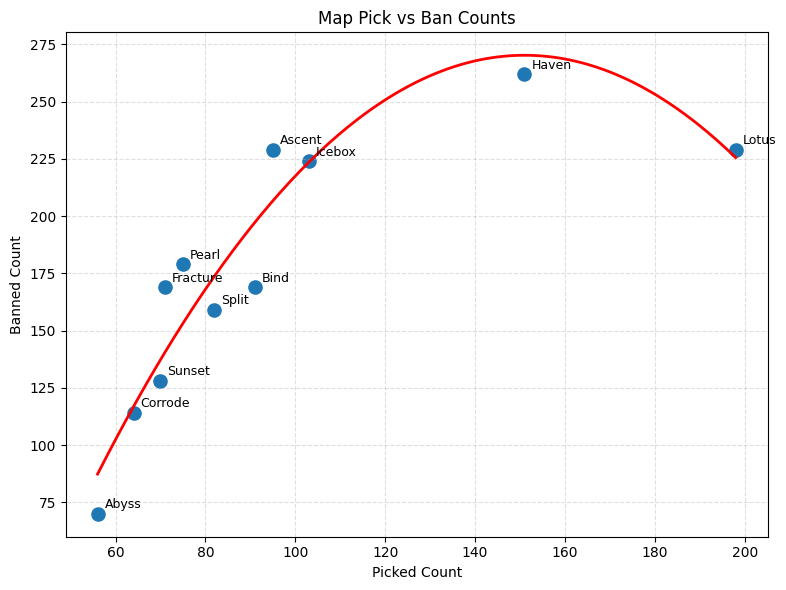

In [24]:
map_action_counts = (
    pd.crosstab(df["Map"], df["Action"])
    .reindex(columns=["ban", "pick"], fill_value=0)
    .sort_index()
)

x = map_action_counts["pick"].to_numpy()
y = map_action_counts["ban"].to_numpy()

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=90, label="Maps")

#line of best fit
degree = 2
coeffs = np.polyfit(x, y, degree)
poly_fn = np.poly1d(coeffs)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = poly_fn(x_fit)
plt.plot(x_fit, y_fit, color="red", linewidth=2, label=f"Best fit (deg {degree})")

# label each dot with map name
for map_name, row in map_action_counts.iterrows():
    plt.annotate(
        map_name,
        (row["pick"], row["ban"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel("Picked Count")
plt.ylabel("Banned Count")
plt.title("Map Pick vs Ban Counts")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

the graph pretty clearly shows a relationship where the more popular a map is to pick to more popular it is to ban, up to a point where the pick rate out weighs the want to ban the map

time to create new data, now that we have an overview of what our data looks like for everyteam, its time to look at what the individual pick/ban rates are for each team

/tmp/ipykernel_50876/2650823939.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


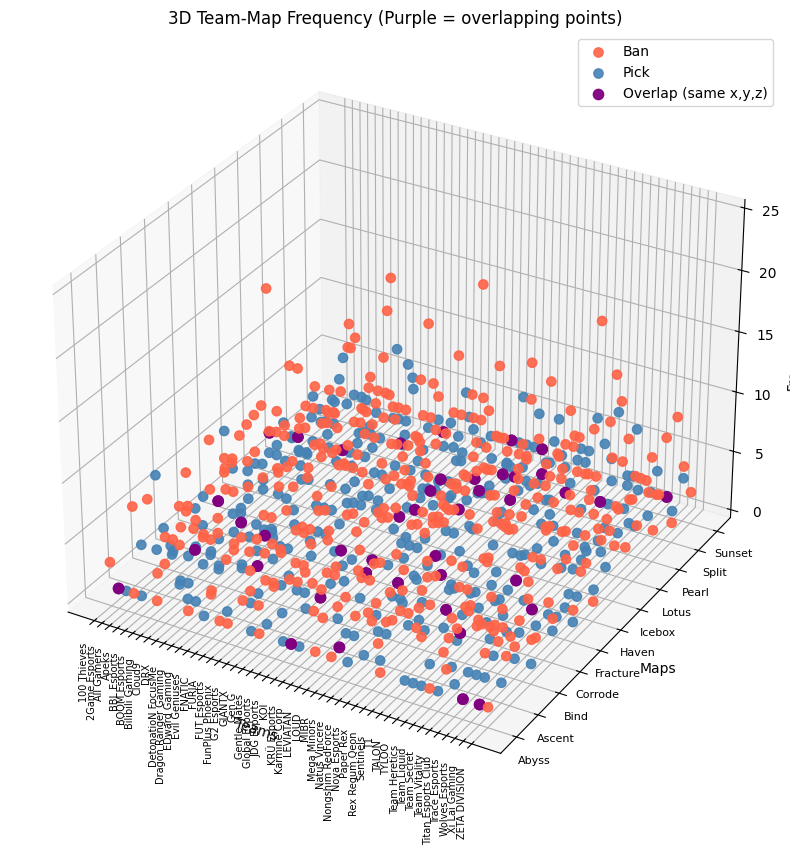

In [25]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

df_plot = df.copy()
df_plot["Action"] = df_plot["Action"].str.lower().str.strip()

# Team + Map + Action frequency
freq = (
    df_plot.groupby(["Team", "Map", "Action"])
    .size()
    .reset_index(name="Frequency")
    .query("Action in ['ban', 'pick'] and Frequency > 0")
)

teams = sorted(freq["Team"].unique())
maps = sorted(freq["Map"].unique())

team_to_x = {team: i for i, team in enumerate(teams)}
map_to_y = {m: i for i, m in enumerate(maps)}

freq["x"] = freq["Team"].map(team_to_x)
freq["y"] = freq["Map"].map(map_to_y)
freq["z"] = freq["Frequency"]

# Find points that share exact same plotted coordinates
overlap_mask = freq.duplicated(subset=["x", "y", "z"], keep=False)

ban_only = freq[(freq["Action"] == "ban") & (~overlap_mask)]
pick_only = freq[(freq["Action"] == "pick") & (~overlap_mask)]
overlap = freq[overlap_mask]

fig = plt.figure(figsize=(22, 10))
ax = fig.add_subplot(111, projection="3d")

if not ban_only.empty:
    ax.scatter(
        ban_only["x"],
        ban_only["y"],
        ban_only["z"],
        c="tomato",
        s=45,
        alpha=0.9,
        label="Ban",
    )
if not pick_only.empty:
    ax.scatter(
        pick_only["x"],
        pick_only["y"],
        pick_only["z"],
        c="steelblue",
        s=45,
        alpha=0.9,
        label="Pick",
    )
if not overlap.empty:
    ax.scatter(
        overlap["x"],
        overlap["y"],
        overlap["z"],
        c="purple",
        s=55,
        alpha=0.95,
        label="Overlap (same x,y,z)",
    )

ax.set_xlabel("Teams")
ax.set_ylabel("Maps")
ax.set_zlabel("Frequency")
ax.set_title("3D Team-Map Frequency (Purple = overlapping points)")

ax.set_xticks(range(len(teams)))
ax.set_xticklabels(teams, rotation=90, fontsize=7)

ax.set_yticks(range(len(maps)))
ax.set_yticklabels(maps, fontsize=8)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

this graph shows reasonbly clearly the more popular maps to ban as well as the ones to pick

The following might be a bit clearer

/tmp/ipykernel_50876/2548434112.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


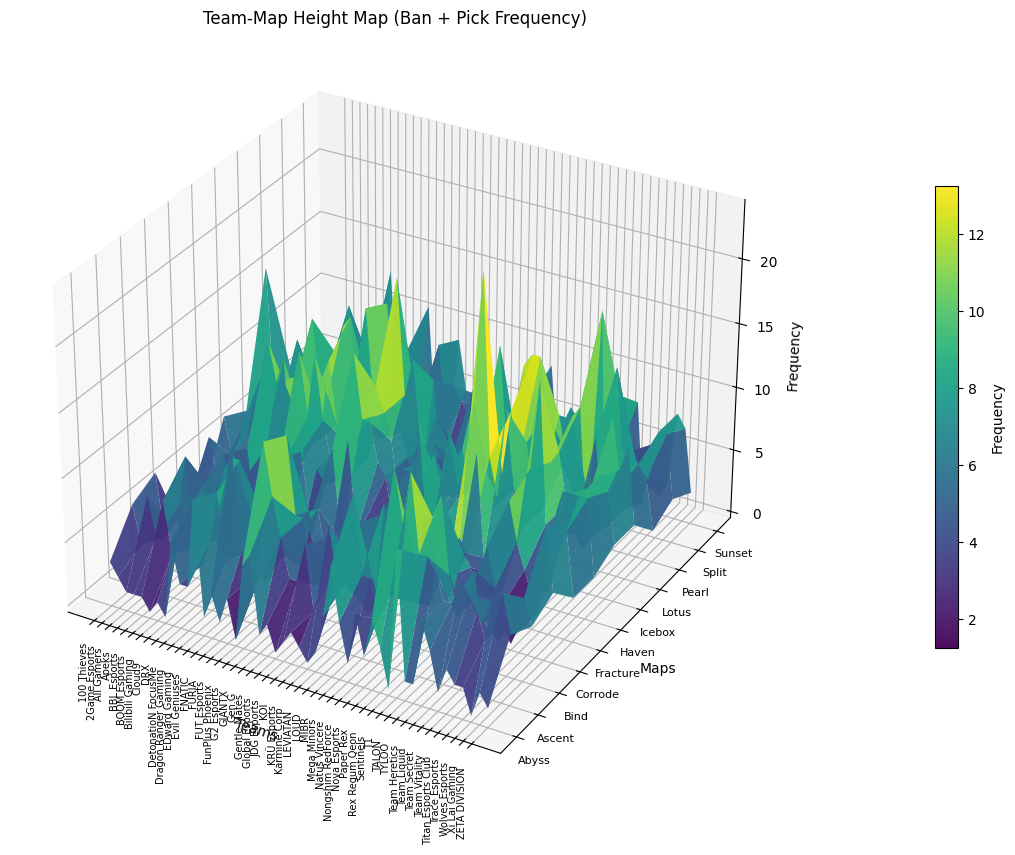

In [26]:
df_plot = df.copy()
df_plot["Action"] = df_plot["Action"].str.lower().str.strip()

# Use both bans + picks together
team_map_height = (
    df_plot[df_plot["Action"].isin(["ban", "pick"])]
    .groupby(["Team", "Map"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

teams = team_map_height.index.tolist()
maps = team_map_height.columns.tolist()

X, Y = np.meshgrid(np.arange(len(teams)), np.arange(len(maps)), indexing="ij")
Z = team_map_height.to_numpy()

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.95)

ax.set_xlabel("Teams")
ax.set_ylabel("Maps")
ax.set_zlabel("Frequency")
ax.set_title("Team-Map Height Map (Ban + Pick Frequency)")

ax.set_xticks(np.arange(len(teams)))
ax.set_xticklabels(teams, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(maps)))
ax.set_yticklabels(maps, fontsize=8)

fig.colorbar(surf, ax=ax, pad=0.1, shrink=0.6, label="Frequency")
plt.tight_layout()
plt.show()

now since we have a thorough idea of the data it is time to start trying to predict

The below code asksfor a team then shows every game of who they played
!clean up so it only shows team a for action a

In [27]:
What_team = input("what team: ").strip().lower()

split_teams = (
    df["Match Name"]
    .str.split(r"\s+vs\s+", n=1, expand=True)
    .apply(lambda s: s.str.strip())
)

left = split_teams[0]
right = split_teams[1]
left_key = left.str.lower()
right_key = right.str.lower()

# keep rows where the match includes the chosen team
involved = left_key.eq(What_team) | right_key.eq(What_team)

results = df.loc[involved, ["Match Name", "Team", "Action", "Map"]].copy()

# force Team A = chosen team, Team B = opponent
results["Team A"] = np.where(
    left_key[involved].eq(What_team), left[involved], right[involved]
)
results["Team B"] = np.where(
    left_key[involved].eq(What_team), right[involved], left[involved]
)

# mark which side made the action
team_key = results["Team"].str.strip().str.lower()
team_a_key = results["Team A"].str.strip().str.lower()
results["Side"] = np.where(team_key.eq(team_a_key), "A", "B")

# combine action + map
results["Action Map"] = (
    results["Action"].astype(str).str.strip()
    + " "
    + results["Map"].astype(str).str.strip()
)

# pair Team A and Team B actions side-by-side per match
results["Turn"] = results.groupby(["Match Name", "Side"]).cumcount()

formatted = (
    results.pivot_table(
        index=["Match Name", "Team A", "Team B", "Turn"],
        columns="Side",
        values="Action Map",
        aggfunc="first",
    )
    .rename(columns={"A": "Team A Action Map", "B": "Team B Action Map"})
    .reset_index()
    .drop(columns="Turn")
    .fillna("")
)

formatted = formatted[
    ["Match Name", "Team A", "Team A Action Map", "Team B", "Team B Action Map"]
]

print(formatted.to_string(index=False))

                     Match Name    Team A Team A Action Map             Team B Team B Action Map
      BOOM Esports vs Paper Rex Paper Rex        ban Ascent       BOOM Esports        ban Icebox
      BOOM Esports vs Paper Rex Paper Rex        pick Lotus       BOOM Esports         pick Bind
      BOOM Esports vs Paper Rex Paper Rex         ban Haven       BOOM Esports        ban Sunset
      BOOM Esports vs Paper Rex Paper Rex         ban Haven       BOOM Esports         ban Split
      BOOM Esports vs Paper Rex Paper Rex        pick Lotus       BOOM Esports     pick Fracture
      BOOM Esports vs Paper Rex Paper Rex         ban Pearl       BOOM Esports        ban Icebox
               DRX vs Paper Rex Paper Rex         ban Abyss                DRX        ban Sunset
               DRX vs Paper Rex Paper Rex        pick Lotus                DRX       pick Ascent
               DRX vs Paper Rex Paper Rex         ban Haven                DRX          ban Bind
               DRX vs Paper Re

now we need to take only team A and team B

In [28]:
team_a = input("team A").strip().lower()
team_b = input("Team b").strip().lower()

split_teams = (
    df["Match Name"]
    .str.split(r"\s+vs\s+", n=1, expand=True)
    .apply(lambda s: s.str.strip())
)

left = split_teams[0]
right = split_teams[1]
left_key = left.str.lower()
right_key = right.str.lower()

teamcombo_mask = (left_key.eq(team_a) & right_key.eq(team_b)) | (
    left_key.eq(team_b) & right_key.eq(team_a)
)

team_combo = df.loc[teamcombo_mask, ["Match Name", "Team", "Action", "Map"]].copy()
team_combo["team_key"] = team_combo["Team"].str.strip().str.lower()

team_a_only = team_combo[team_combo["team_key"].eq(team_a)].copy()

if team_a_only.empty:
    print("No rows found for that Team A vs Team B matchup.")
else:
    team_a_only["Action"] = team_a_only["Action"].astype(str).str.strip().str.lower()
    team_a_only["Map"] = team_a_only["Map"].astype(str).str.strip()
    print(team_a_only[["Match Name", "Team", "Action", "Map"]].to_string(index=False))

No rows found for that Team A vs Team B matchup.


lets see what the most popular maps for each team is now

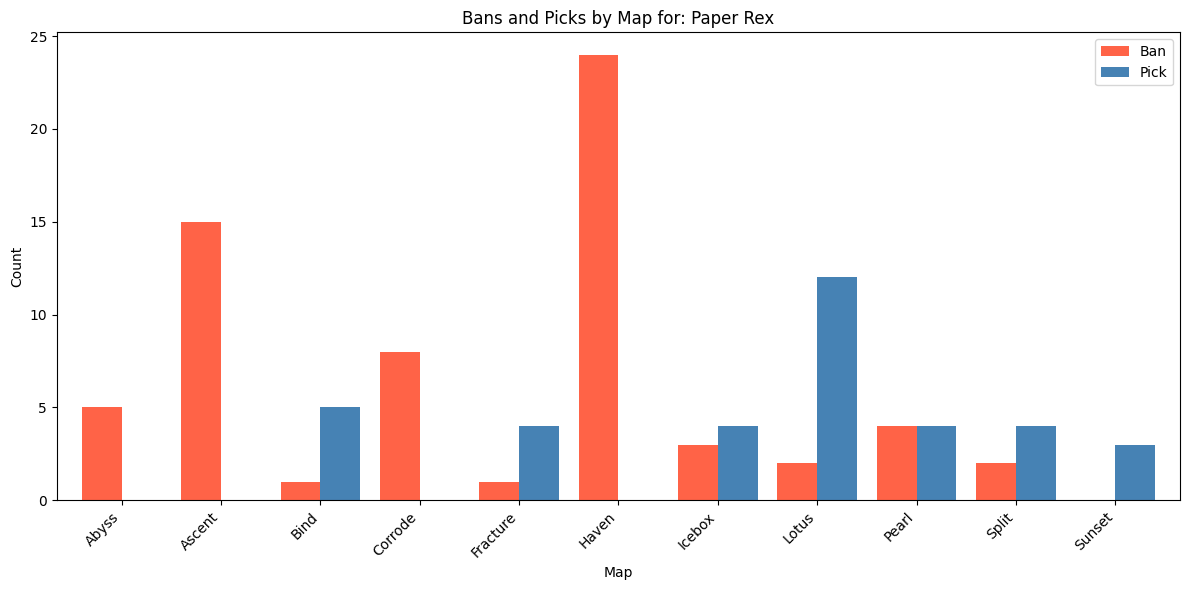

In [29]:
team_name = input("what team do you want to predict ").strip().lower()

team_rows = df[df["Team"].astype(str).str.strip().str.lower().eq(team_name)].copy()

if team_rows.empty:
    print("No rows found for that team.")
else:
    team_rows["Action"] = team_rows["Action"].astype(str).str.strip().str.lower()
    team_rows["Map"] = team_rows["Map"].astype(str).str.strip()

    map_action_counts = (
        pd.crosstab(team_rows["Map"], team_rows["Action"])
        .reindex(columns=["ban", "pick"], fill_value=0)
        .sort_index()
    )

    ax = map_action_counts.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8,
        color=["tomato", "steelblue"],
    )
    ax.set_title(f"Bans and Picks by Map for: {team_rows['Team'].iloc[0]}")
    ax.set_xlabel("Map")
    ax.set_ylabel("Count")
    ax.legend(["Ban", "Pick"])
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

most data wrangling is unnecessary:
- there are no null values
- duplicates are part of a count, which is what is being measured (the AMOUNT of picks)

but:
- duplicates will be consolidated into a team specific sheet
- outliers are wanted as it gives a clear indicator of what team prefers what map
- features are catagorical and will be scaled to a sigmoid function

so we want to create a temporary csv to contain the data the model will get based on the team

In [30]:

team_rows = df[df["Team"].astype(str).str.strip().str.lower().eq(team_name)].copy()

if team_rows.empty:
    print("No rows found for that team.")
    teamdata = pd.DataFrame(columns=["team","map", "ban", "pick"])
else:
    team_rows["Action"] = team_rows["Action"].astype(str).str.strip().str.lower()
    team_rows["Map"] = team_rows["Map"].astype(str).str.strip()

    # one row per map with number of bans by this team
    teamdata = (
        pd.crosstab(team_rows["Map"], team_rows["Action"])
        .reindex(columns=["ban", "pick"], fill_value=0)
        .reset_index()
        .rename(columns={"Map": "map"})
        .sort_values("map")
        .reset_index(drop=True)
    )

    teamdata.insert(0, "team", team_rows["Team"].iloc[0])

print(teamdata)
if not teamdata.empty:
    safe_team = team_name.replace(" ", "_")
    output_path = Path.cwd() / f"teamdata_{safe_team}.csv"
    teamdata.to_csv("teamdata.csv", index=False)
    print(f"Saved: {output_path}")
else:
    print("teamdata is empty, not saving.")

Action       team       map  ban  pick
0       Paper Rex     Abyss    5     0
1       Paper Rex    Ascent   15     0
2       Paper Rex      Bind    1     5
3       Paper Rex   Corrode    8     0
4       Paper Rex  Fracture    1     4
5       Paper Rex     Haven   24     0
6       Paper Rex    Icebox    3     4
7       Paper Rex     Lotus    2    12
8       Paper Rex     Pearl    4     4
9       Paper Rex     Split    2     4
10      Paper Rex    Sunset    0     3
Saved: /workspaces/2026SE_MLOPSTask_Max.H/1.Design/teamdata_paper_rex.csv


now we can add it to the model to plot

the model cannot just be trained based of that though so the rest of the data will be added but with a lower relevance

In [31]:
if "team_name" not in locals():
    raise NameError("Run cell 36 first so 'team_name' is defined.")

excluded_team = str(team_name).strip().lower()

all_rows = df.copy()
all_rows["Team"] = all_rows["Team"].astype(str).str.strip()
all_rows["Map"] = all_rows["Map"].astype(str).str.strip()
all_rows["Action"] = all_rows["Action"].astype(str).str.strip().str.lower()

# remove the chosen team from cell 36
all_rows = all_rows[~all_rows["Team"].str.lower().eq(excluded_team)].copy()

# keep only ban/pick actions
all_rows = all_rows[all_rows["Action"].isin(["ban", "pick"])].copy()

# counts per map from remaining teams
mapdata = (
    pd.crosstab(all_rows["Map"], all_rows["Action"])
    .reindex(columns=["ban", "pick"], fill_value=0)
    .reset_index()
    .rename(columns={"Map": "map"})
    .sort_values("map")
    .reset_index(drop=True)
)

print(f"Excluded team: {team_name}")
print(mapdata)

output_path = Path.cwd() / "alldata.csv"
mapdata.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Excluded team: paper rex
Action       map  ban  pick
0          Abyss   65    56
1         Ascent  214    95
2           Bind  168    86
3        Corrode  106    64
4       Fracture  168    67
5          Haven  238   151
6         Icebox  221    99
7          Lotus  227   186
8          Pearl  175    71
9          Split  157    78
10        Sunset  128    67
Saved: /workspaces/2026SE_MLOPSTask_Max.H/1.Design/alldata.csv


no we can combine them into a compelte data table for specfic teams

In [32]:
# Load both datasets
all_df = pd.read_csv("alldata.csv")
team_df = pd.read_csv("teamdata.csv")

# Clean keys
all_df["map"] = all_df["map"].astype(str).str.strip()
team_df["map"] = team_df["map"].astype(str).str.strip()

# Ensure numeric
for col in ["ban", "pick"]:
    all_df[col] = pd.to_numeric(all_df[col], errors="coerce").fillna(0)
    team_df[col] = pd.to_numeric(team_df[col], errors="coerce").fillna(0)

# Preview both datasets to confirm they are ready for model.ipynb
print("=== alldata.csv (all teams except chosen) ===")
print(all_df.to_string(index=False))

print("\n=== teamdata.csv (chosen team only) ===")
print(team_df.to_string(index=False))

print("\nReady for model.ipynb — specific.csv is no longer needed.")
print(f"Total team picks: {int(team_df['pick'].sum())}")
print(f"Total global picks: {int(all_df['pick'].sum())}")

=== alldata.csv (all teams except chosen) ===
     map  ban  pick
   Abyss   65    56
  Ascent  214    95
    Bind  168    86
 Corrode  106    64
Fracture  168    67
   Haven  238   151
  Icebox  221    99
   Lotus  227   186
   Pearl  175    71
   Split  157    78
  Sunset  128    67

=== teamdata.csv (chosen team only) ===
     team      map  ban  pick
Paper Rex    Abyss    5     0
Paper Rex   Ascent   15     0
Paper Rex     Bind    1     5
Paper Rex  Corrode    8     0
Paper Rex Fracture    1     4
Paper Rex    Haven   24     0
Paper Rex   Icebox    3     4
Paper Rex    Lotus    2    12
Paper Rex    Pearl    4     4
Paper Rex    Split    2     4
Paper Rex   Sunset    0     3

Ready for model.ipynb — specific.csv is no longer needed.
Total team picks: 36
Total global picks: 1020
